In [65]:
#!pip install datasets
#!pip install tokenizers==0.10.0rc1
#!pip install wandb

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np

import datasets
import tokenizers
import wandb
from tqdm.auto import tqdm

import matplotlib.pyplot as plt

c:\Users\s.simonenko\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## О формате заданий

### Coding tasks


Место для вашего кода отмечено блоками `# YOUR CODE STARTS` ... `#YOUR CODE ENDS` и ваше решение должно быть строго между ними. 

Чтобы решить задачу, вам придётся смотреть в документацию соответствующего фреймворка. Этот навык очень важен, и в начале мы будем намекать вам на название метода, который вам нужно использовать. Такой подход позволит плавно приблизить вас к более реалистичным задачам.



![image.png](https://files.realpython.com/media/Practical-Text-Classification-with-Keras-and-Python_Watermark.fe326bd75146.jpg)

Image source: [тык](https://realpython.com/python-keras-text-classification/)

In [2]:
text_dataset = datasets.load_dataset("imdb")

**IMDB** - это датасет по классификации эмоциональной окраски. Вам нужно предсказать положительный ли отзыв к фильму по его тексту. Это довольно простая задача и она хорошо решается даже линейными моделями. Для доступа к нему мы используем библиотеку `datasets` - она содержит в себе много интересных текстовых датасетов.

Тренировочная и тстовая части IMDB достаточно большие - каждая состоит из 25 тысяч примеров.

In [3]:
text_dataset

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 25000
    })
    unsupervised: Dataset({
        features: ['text', 'label'],
        num_rows: 50000
    })
})

Как мы видим, классы сбалансированны, что позволяет использовать accuracy как простую и интерпретируемую метрику, хорошо показывающую качество модели.

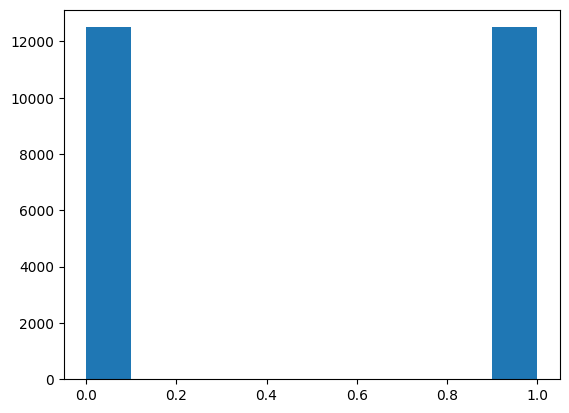

In [4]:
train_labels = [e['label'] for e in text_dataset['train']]
plt.hist(train_labels)
plt.show()

# Classification using a linear model

Линейная модель - очень сильный бейзлайн и в некоторых задачах классификации вам даже не надо идти дальше линейной модели - она уже достаточно хороша. А также её можно написать менее чем в 10 строчек. Поэтому всегда стоит начинать решение любой задачи с ленейного бейзлайна.

Давайте вспомним библиотеку `sklearn` и напишем линейную модельку. Для векторизации текста мы будем использовать `TfidfVectorizer`, а в качестве модели `LogisticRegression`.


In [60]:
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer

In [61]:
# TASK 1.1: create TfidfVectorizer object and fit it on out training set texts
# Our implementation is 2 lines
# YOUR CODE STARTS
vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_features=50000, sublinear_tf=True, stop_words='english')
X_train = vectorizer.fit_transform(text_dataset["train"]["text"])
# YOUR CODE ENDS

In [62]:
# TASK 1.2:
# 1. convert your texts to tf-idf vectors using .transform (training texts and test texts too)
# 2. convert your labels into numpy arrays (both training and test labels)
# Or implementatin is 4 lines

# YOUR CODE STARTS
X_train = vectorizer.transform(text_dataset["train"]["text"])
X_test  = vectorizer.transform(text_dataset["test"]["text"])
y_train = np.array(text_dataset["train"]["label"])
y_test  = np.array(text_dataset["test"]["label"])
# YOUR CODE ENDS

In [63]:
X_train, y_train

(<Compressed Sparse Row sparse matrix of dtype 'float64'
 	with 2740996 stored elements and shape (25000, 50000)>,
 array([0, 0, 0, ..., 1, 1, 1]))

In [64]:
# TASK 1.3: create LogisticRegression model object and fit the model
# Our implementation is 2 lines
# YOUR CODE STARTS
model = LogisticRegression(
#            solver='saga',
            max_iter=1000,
            n_jobs=-1,
            random_state=42
        )

# обучаем
model.fit(X_train, y_train)

print(model.n_iter_)
# YOUR CODE ENDS

[10]


А теперь мы используем нашу модель для того, чтобы предсказать классы на тестовом сете и считаем accuracy.

In [65]:
predictions = model.predict(X_test)

print(predictions)
print(y_test)

[0 0 0 ... 1 0 1]
[0 0 0 ... 1 1 1]


In [66]:
# note that we can use vector operations, because we deal with numpy tensors
accuracy = (predictions == y_test).mean()
#accuracy
print("LogisticRegretion(LogReg)")
print(f"Accuracy = {accuracy:.4%}")

LogisticRegretion(LogReg)
Accuracy = 88.8680%


**OMG so accurate, much machine learning**

Давайте предскажем позитивны ли такие комментарии:

In [67]:
positive_comment = 'This movie is awesome!'

vec = vectorizer.transform([positive_comment])
model.predict(vec)

array([1])

In [68]:
negative_comment = 'This movie is awful!'

vec = vectorizer.transform([negative_comment])
model.predict(vec)

array([0])

Как мы увидели, даже такая простая модель может хорошо классифицировать текст (accuracy 0.9 - это довольно много, тк выборка сбалансированна).

Кстати, использование модели LinearSVM обычно работает даже лучше, чем логистическая регрессия. Рекомендуем попробовать и сравнить.

Что такое SVM: [тык](https://towardsdatascience.com/support-vector-machine-introduction-to-machine-learning-algorithms-934a444fca47)

Ещё один простой метод улучшить линейную модель - использовать n-gram в вашем TF-IDF. Не забудьте указать параметр `max_features` (хорошое число 50 000), а то при большом количестве фичей модель может начать переобучаться.

In [69]:
from sklearn.svm import LinearSVC 
from sklearn.metrics import accuracy_score, classification_report
svm = LinearSVC(C=1.0,loss='squared_hinge',max_iter=5000,random_state=42)
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [70]:
for C in [0.01, 0.1, 0.5, 1, 2, 5, 10]:
    svm = LinearSVC(C=C, max_iter=1000, random_state=42)
    svm.fit(X_train, y_train)
    print(C, accuracy_score(y_test, svm.predict(X_test)))

0.01 0.86064
0.1 0.88852
0.5 0.88616
1 0.88092
2 0.87512
5 0.86888
10 0.86656


In [71]:
print("LinearSVC (Linear SVM)")
print(f"Accuracy = {acc_svm:.4%}")

LinearSVC (Linear SVM)
Accuracy = 88.0920%


в данном случае LogisticRegression показала себя лучше.